<a href="https://colab.research.google.com/github/manansethi1205/Fashion-MNIST-image-classification/blob/main/fmnist_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {device}")

Using device : cuda


In [19]:
torch.manual_seed(42)

In [20]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


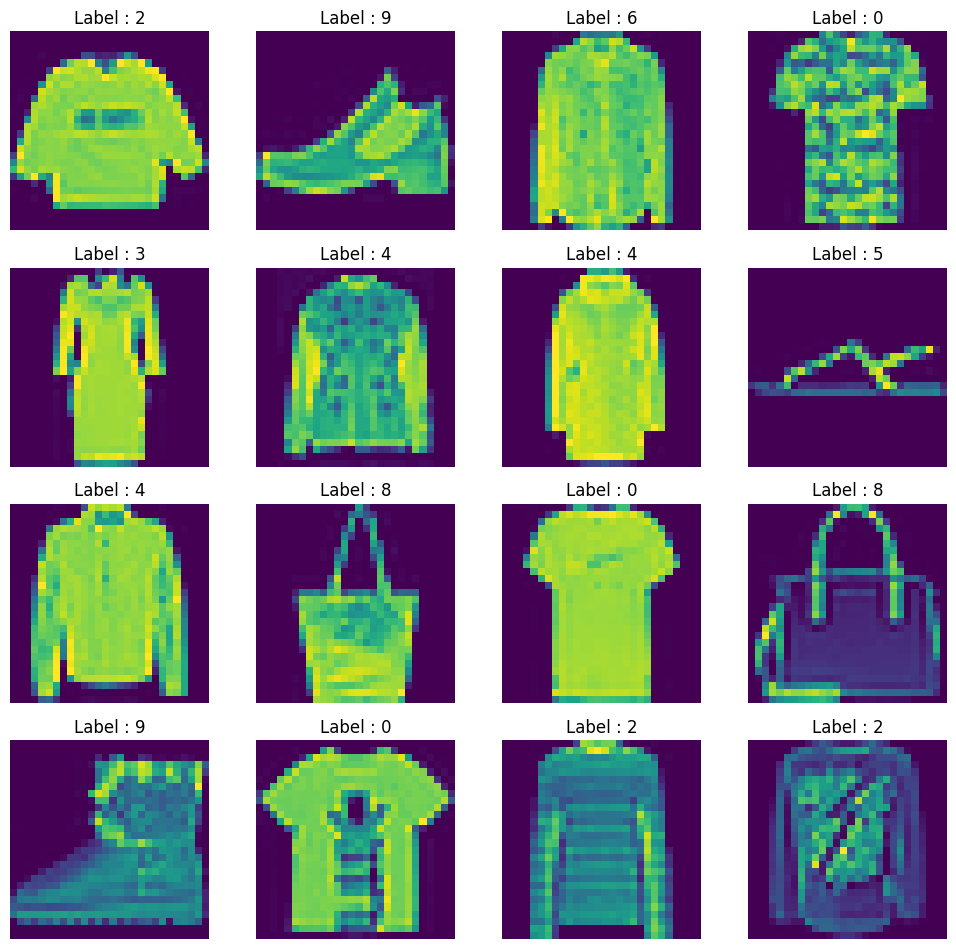

In [21]:
fig,axes = plt.subplots(4,4,figsize = (10,10))

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [22]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [24]:
X_train = X_train/255.0
X_test = X_test/255.0

In [25]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [26]:
# custom dataset class

class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype = torch.float32)
    self.labels = torch.tensor(labels,dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [27]:
train_dataset = CustomDataset(X_train,y_train)

In [28]:
len(train_dataset)

10231

In [29]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0039, 0.0039, 0.0039, 0.0039, 0.0039, 0.0000, 0.3961, 0.6196,
         0.4510, 0.3373, 0.1176, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.0078, 0.0000, 0.2745, 0.7412,
         0.6667, 0.7216, 0.7490, 0.6039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0039, 0.0000, 0.0000, 0.0118, 0.0039, 0.0000, 0.2471, 0.7020,
         0.7451, 0.7255, 0.6471, 0.7216, 0.2000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0039, 0.0118, 0.0039, 0.0000, 0.0000, 0.3373, 0.7647,
         0.6667, 0.7255, 0.7961, 0.6667, 0.5569, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [30]:
# create test dataset
test_dataset = CustomDataset(X_test,y_test)

In [31]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32,shuffle = False)

In [32]:
from torch.nn.modules.activation import ReLU
class MyModel(nn.Module):

  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128), #batch normalization
        nn.ReLU(),
        nn.Dropout(p = 0.3), #applying dropouts
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p = 0.3),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [33]:
epochs = 100
learning_rate = 0.001

In [34]:
# instantiate the model
model = MyModel(X_train.shape[1])
model = model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay = 1e-4)

In [35]:
# number of batches
len(train_loader)

320

In [50]:
def calculate_accuracy(model, dataloader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in dataloader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    model.train()

    return 100 * correct / total

In [51]:
train_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_epoch_loss += loss.item()

    avg_epoch_loss = total_epoch_loss / len(train_loader)

    train_losses.append(avg_epoch_loss)

    # Calculate accuracies
    train_acc = calculate_accuracy(model, train_loader)
    test_acc = calculate_accuracy(model, test_loader)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {avg_epoch_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch 1/100 | Loss: 0.2673 | Train Acc: 99.18% | Test Acc: 85.42%
Epoch 2/100 | Loss: 0.2509 | Train Acc: 99.10% | Test Acc: 85.93%
Epoch 3/100 | Loss: 0.2447 | Train Acc: 98.67% | Test Acc: 86.00%
Epoch 4/100 | Loss: 0.2604 | Train Acc: 98.41% | Test Acc: 84.87%
Epoch 5/100 | Loss: 0.2405 | Train Acc: 98.47% | Test Acc: 84.91%
Epoch 6/100 | Loss: 0.2358 | Train Acc: 99.19% | Test Acc: 85.81%
Epoch 7/100 | Loss: 0.2383 | Train Acc: 98.92% | Test Acc: 85.81%
Epoch 8/100 | Loss: 0.2300 | Train Acc: 98.83% | Test Acc: 85.85%
Epoch 9/100 | Loss: 0.2249 | Train Acc: 98.68% | Test Acc: 85.69%
Epoch 10/100 | Loss: 0.2309 | Train Acc: 98.93% | Test Acc: 85.97%
Epoch 11/100 | Loss: 0.2321 | Train Acc: 98.75% | Test Acc: 85.85%
Epoch 12/100 | Loss: 0.2344 | Train Acc: 98.65% | Test Acc: 85.57%
Epoch 13/100 | Loss: 0.2254 | Train Acc: 98.92% | Test Acc: 86.28%
Epoch 14/100 | Loss: 0.2193 | Train Acc: 98.91% | Test Acc: 86.16%
Epoch 15/100 | Loss: 0.2099 | Train Acc: 98.67% | Test Acc: 85.77%
Epoc

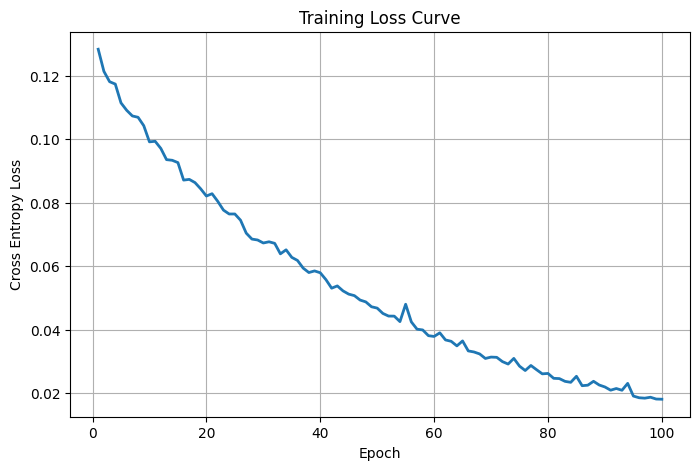

In [44]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

In [45]:
model.eval()

MyModel(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

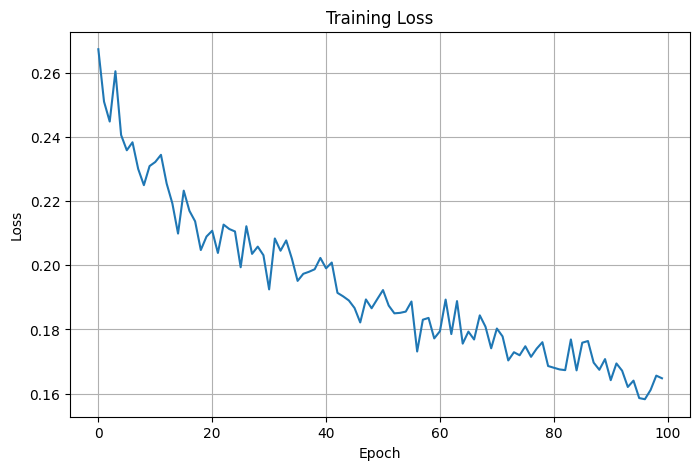

In [52]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

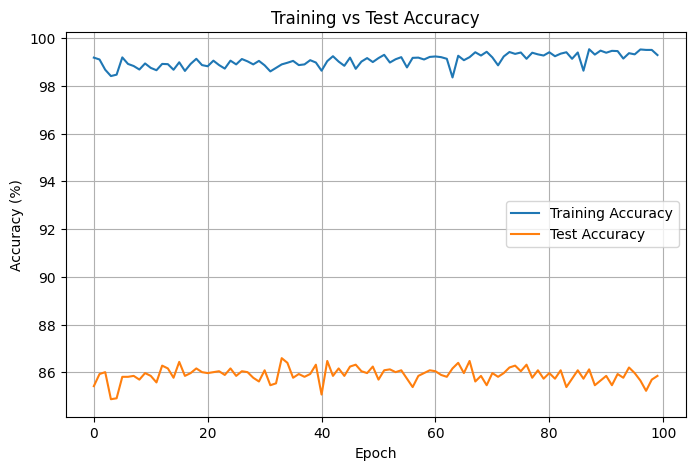

In [53]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.title("Training vs Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

<Figure size 1000x1000 with 0 Axes>

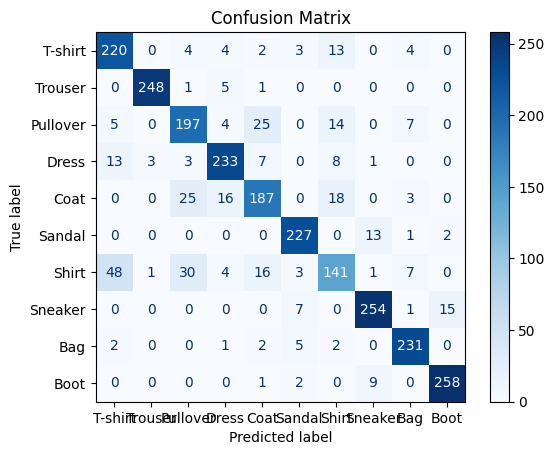

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "T-shirt",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Boot"
    ]
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [55]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=[
        "T-shirt",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Boot"
    ]
))

              precision    recall  f1-score   support

     T-shirt       0.76      0.88      0.82       250
     Trouser       0.98      0.97      0.98       255
    Pullover       0.76      0.78      0.77       252
       Dress       0.87      0.87      0.87       268
        Coat       0.78      0.75      0.76       249
      Sandal       0.92      0.93      0.93       243
       Shirt       0.72      0.56      0.63       251
     Sneaker       0.91      0.92      0.92       277
         Bag       0.91      0.95      0.93       243
        Boot       0.94      0.96      0.95       270

    accuracy                           0.86      2558
   macro avg       0.86      0.86      0.85      2558
weighted avg       0.86      0.86      0.86      2558



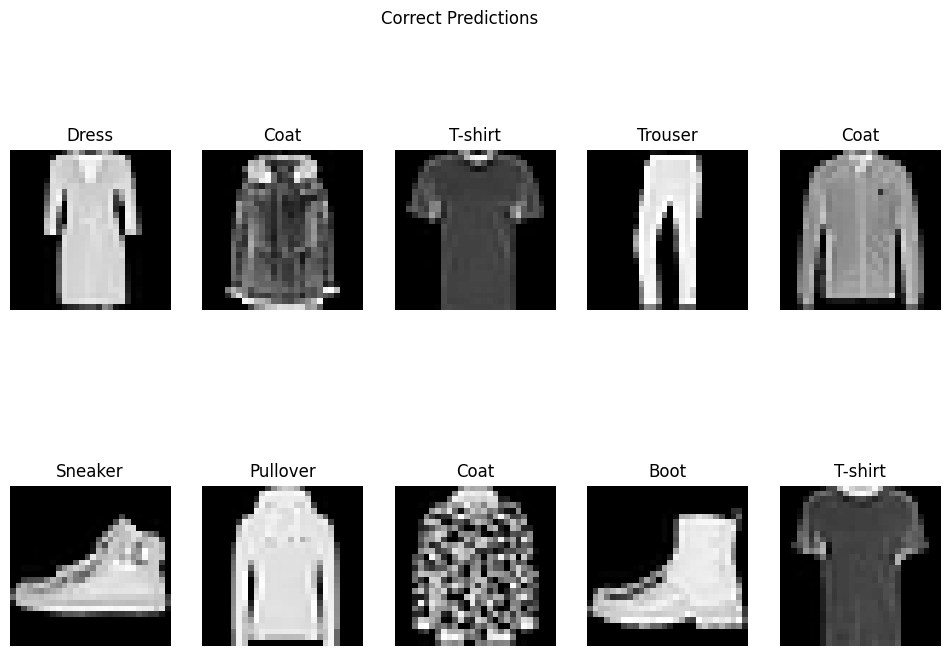

In [56]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Boot"
]

model.eval()

shown = 0

plt.figure(figsize=(12,8))

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        for i in range(len(images)):

            if preds[i] == labels[i]:

                shown += 1

                plt.subplot(2,5,shown)

                plt.imshow(images[i].cpu().reshape(28,28), cmap='gray')

                plt.title(class_names[preds[i]])

                plt.axis("off")

                if shown == 10:
                    break

        if shown == 10:
            break

plt.suptitle("Correct Predictions")
plt.show()

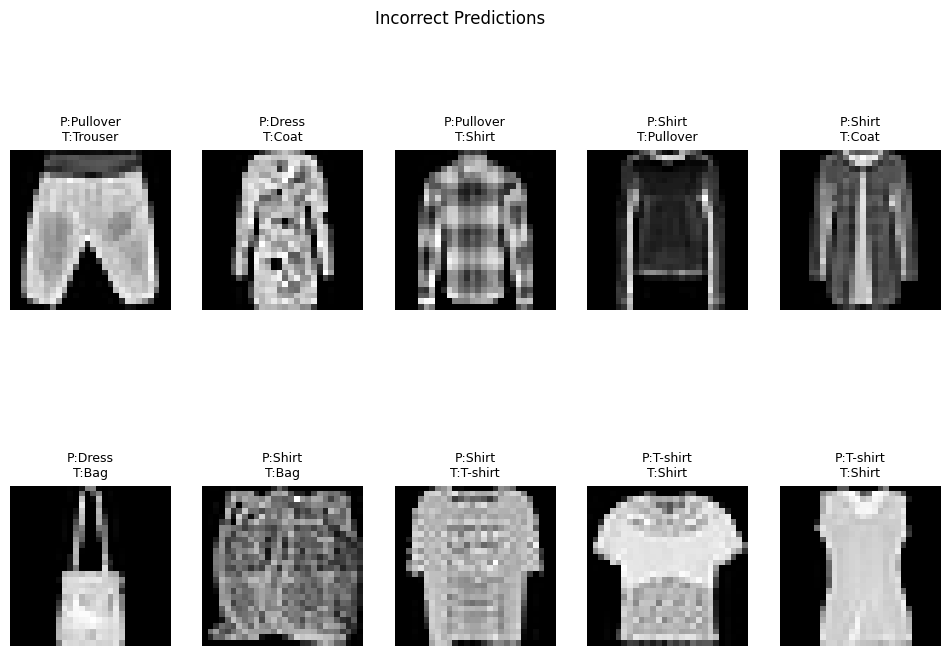

In [57]:
model.eval()

shown = 0

plt.figure(figsize=(12,8))

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        for i in range(len(images)):

            if preds[i] != labels[i]:

                shown += 1

                plt.subplot(2,5,shown)

                plt.imshow(images[i].cpu().reshape(28,28), cmap='gray')

                plt.title(
                    f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}",
                    fontsize=9
                )

                plt.axis("off")

                if shown == 10:
                    break

        if shown == 10:
            break

plt.suptitle("Incorrect Predictions")
plt.show()